In [1]:
from inspectre import Inspectre
import numpy as np
from scipy import integrate as it
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline as IUS
from scipy.interpolate import CubicSpline

In [2]:
a = 0.5
p = 10.0
e = 0.2
x = 1
mass = 1.0
err = 1e-15
mode="equatorial"

insp = Inspectre(
    spin=a,
    semilatus_rectum=p,
    eccentricity=e,
    x=x,
    mass=mass,
    err=err,
    mode=mode
)

In [3]:
print(f"""Orbital parameters: 
Energy \t\t = {insp.energy},
Angular momentum = {insp.angular_momentum},
Carter constant  = {insp.carter_constant}""")
print()
print(f"""Frequencies: 
Azimuthal: \t = {insp.omega_phi},
Radial:  \t = {insp.omega_r},
Polar: \t\t = {insp.omega_theta}""")

Orbital parameters: 
Energy 		 = 0.9554917116351583,
Angular momentum = 3.5965610903774414,
Carter constant  = -2.5847692791459328e-15

Frequencies: 
Azimuthal: 	 = 0.029689018630018806,
Radial:  	 = 0.021370474208095996,
Polar: 		 = 0.0


In [22]:
N=18
print(2**N)
insp.generate_equatorial_trajectory(num_pts=2**N)

262144


In [23]:
insp.resample_trajectory(num_pts=2**N)

In [24]:
src_mn = insp.source_mn_integrand_along_trajectory(2, 1, 10.1, np.pi/2-0.1)

In [25]:
spdata = IUS(src_mn.T[0], src_mn.T[1], k=3).integral(0,src_mn.T[0][-1])
sim_lam = it.simpson(src_mn.T[1], x=src_mn.T[0])
print(spdata)
print(sim_lam)

0.01131705575018499
0.011317055750185614


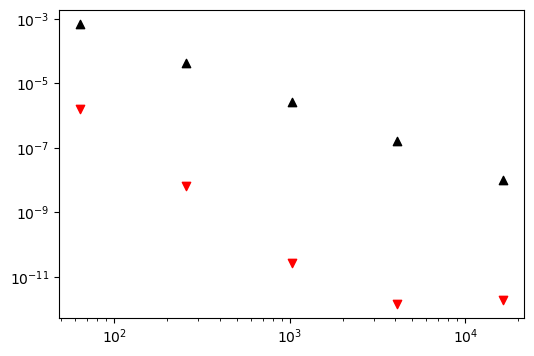

In [26]:
plt.figure(figsize=(6,4))
for i in [6, 8, 10, 12, 14]:
    insp.generate_equatorial_trajectory(num_pts=2**i)
    src_mn = insp.source_mn_integrand_along_trajectory(2, 1, 10.1, np.pi/2-0.1)
    
    tres = src_mn.T[0]
    le = len(tres)
    trapz = np.trapezoid(src_mn.T[1], x=tres)
    simps = it.simpson(src_mn.T[1], x=tres)
    trapz_rs = 1.0 - trapz / spdata
    simps_rs = 1.0 - simps / spdata
    plt.scatter(le, abs(trapz_rs), marker='^', c='k')
    plt.scatter(le, abs(simps_rs), marker='v', c='r')

plt.yscale('log')
plt.xscale('log')
plt.show()

In [27]:
insp.generate_equatorial_trajectory(num_pts=2**18)
insp.resample_trajectory(num_pts=2**18)

In [28]:
src_mn = insp.source_mn_integrand_along_trajectory(2, 1, 10.1, np.pi/2-0.1)

In [29]:
spdata = IUS(src_mn.T[0], src_mn.T[1], k=3).integral(0,src_mn.T[0][-1])
sim_lam = it.simpson(src_mn.T[1], x=src_mn.T[0])
print(spdata)
print(sim_lam)

0.01131705575018499
0.011317055750185614


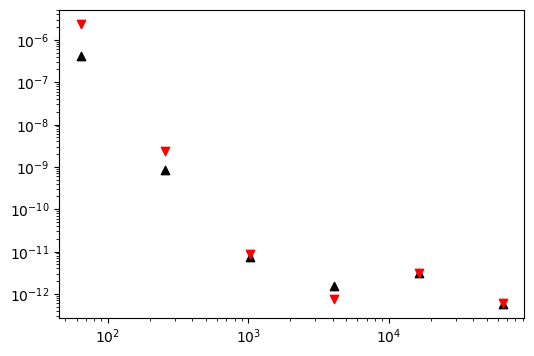

In [30]:
plt.figure(figsize=(6,4))
for i in [6, 8, 10, 12, 14, 16]:
    insp.generate_equatorial_trajectory(num_pts=2**i)
    insp.resample_trajectory(num_pts=2**i)
    src_mn = insp.source_mn_integrand_along_trajectory(2, 1, 10.1, np.pi/2-0.1)
    
    tres = src_mn.T[0]
    le = len(tres)
    trapz = np.trapezoid(src_mn.T[1], x=tres)
    simps = it.simpson(src_mn.T[1], x=tres)
    trapz_rs = 1.0 - trapz / spdata
    simps_rs = 1.0 - simps / spdata
    plt.scatter(le, abs(trapz_rs), marker='^', c='k')
    plt.scatter(le, abs(simps_rs), marker='v', c='r')

plt.yscale('log')
plt.xscale('log')
plt.show()